**Practical 2**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn import preprocessing

In [ ]:
# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving imdb_dataset.csv to imdb_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("imdb_dataset.csv")
print(df.head())

                                  review sentiment
0  I loved this movie, it was fantastic!  positive
1          Terrible film, waste of time.  negative
2        Amazing acting and great story.  positive
3          Worst movie I have ever seen.  negative
4  It was okay, not the best but decent.  positive


In [ ]:
# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))  # list of common words
lemmatizer = WordNetLemmatizer()  # for converting words to base form

In [ ]:
# Function for text preprocessing
def preprocess_text(text):
    tokens = word_tokenize(text)  # split text into words

    # Remove stopwords (like 'is', 'the', etc.)
    tokens = [word for word in tokens if word.lower() not in stop_words]

    # Convert words to base form (running → run)
    tokens = [lemmatizer.lemmatize(word.lower()) for word in tokens]

    return ' '.join(tokens)  # join words back to sentence


In [ ]:
# Apply preprocessing to all reviews
df['review'] = df['review'].apply(preprocess_text)

In [ ]:
# Convert sentiment (positive/negative) into numbers (1/0)
le = preprocessing.LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [ ]:
# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

In [ ]:
# Convert text data into numerical form using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)

X_train_bow = vectorizer.fit_transform(X_train)  # train data
X_test_bow = vectorizer.transform(X_test)

In [ ]:
# Train KNN model
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train_bow, y_train)


KNeighborsClassifier()

In [ ]:
# Predict on test data
y_pred = clf.predict(X_test_bow)

In [ ]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5


In [ ]:
# Show classification report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

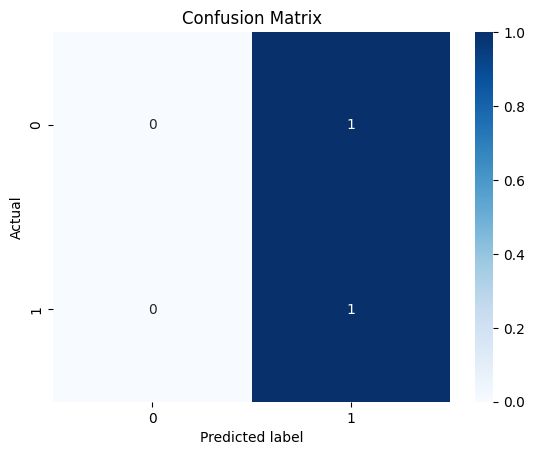

In [ ]:
# Visualize confusion matrix using heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted label")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**PracticL 3**

In [ ]:
import pandas as pd

data = {
    "Comments": [
        "The product is amazing and works perfectly",
        "I am very happy with the service",
        "This is a bad experience",
        "The support team is excellent",
        "I feel disappointed with the quality",
        "Awesome features and great performance",
        "Terrible customer service",
        "The product is good but delivery was slow",
        "I am satisfied with the purchase",
        "This is the worst product I have used",
        "Amazing design and easy to use",
        "The app keeps crashing",
        "Very happy with customer support",
        "Not worth the price",
        "The experience was okay",
        "Excellent quality and fast delivery",
        "Bad packaging but product is good",
        "I love this product",
        "Awful experience",
        "It is just average"
    ],
    "Category": [
        "positive","positive","negative","positive","negative",
        "positive","negative","neutral","positive","negative",
        "positive","negative","positive","negative","neutral",
        "positive","neutral","positive","negative","neutral"
    ]
}

df = pd.DataFrame(data)
df.to_csv("companyfeedback.csv", index=False)

In [ ]:
from google.colab import files
files.download("companyfeedback.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Sample dataset (replace with your CSV file if needed)
data = pd.read_csv('companyfeedback.csv')

# List of polarity words
positive_words = ["good", "happy", "excellent", "awesome", "amazing"]
negative_words = ["bad", "sad", "terrible", "awful", "disappointing"]

# Function to classify document based on polarity words
def classify_document(document):
    pos_count = sum(1 for word in document.split() if word.lower() in positive_words)
    neg_count = sum(1 for word in document.split() if word.lower() in negative_words)

    if pos_count > neg_count:
        return "positive"
    elif neg_count > pos_count:
        return "negative"
    else:
        return "neutral"

# Apply classification
data['predicted_sentiment'] = data['Comments'].apply(classify_document)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    data['Comments'], data['Category'], test_size=0.2, random_state=42
)

# Convert text data into numerical features
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

# Train Multinomial Naive Bayes classifier
classifier = MultinomialNB()
classifier.fit(X_train_counts, y_train)

# Prediction
y_pred = classifier.predict(X_test_counts)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", round(accuracy, 2))
print("Classification Report:\n", report)

Accuracy: 0.5
Classification Report:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00         0
     neutral       0.00      0.00      0.00         0
    positive       1.00      0.50      0.67         4

    accuracy                           0.50         4
   macro avg       0.33      0.17      0.22         4
weighted avg       1.00      0.50      0.67         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Sample dataset (replace with your CSV file if needed)
data = pd.read_csv('companyfeedback.csv')

In [ ]:
positive_words = ["good", "happy", "excellent", "awesome", "amazing"]
negative_words = ["bad", "sad", "terrible", "awful", "disappointing"]

In [ ]:
# Function to classify document based on polarity words
def classify_document(document):
    pos_count = sum(1 for word in document.split() if word.lower() in positive_words)
    neg_count = sum(1 for word in document.split() if word.lower() in negative_words)

    if pos_count > neg_count:
        return "positive"
    elif neg_count > pos_count:
        return "negative"
    else:
        return "neutral"


In [ ]:
# Apply classification
data['predicted_sentiment'] = data['Comments'].apply(classify_document)

In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split( data['Comments'], data['Category'], test_size=0.2, random_state=42 )

In [ ]:
# Convert text data into numerical features
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

In [ ]:
# Train Multinomial Naive Bayes classifier
classifier = MultinomialNB()
classifier.fit(X_train_counts, y_train)

MultinomialNB()

In [ ]:
# Train Multinomial Naive Bayes classifier
classifier = MultinomialNB()
classifier.fit(X_train_counts, y_train)

MultinomialNB()

In [ ]:
# Prediction
y_pred = classifier.predict(X_test_counts)

In [ ]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("Accuracy:", round(accuracy, 2))
print("Classification Report:\n", report)

Accuracy: 0.5
Classification Report:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00         0
     neutral       0.00      0.00      0.00         0
    positive       1.00      0.50      0.67         4

    accuracy                           0.50         4
   macro avg       0.33      0.17      0.22         4
weighted avg       1.00      0.50      0.67         4



**Practical 4**

In [ ]:
# Import required libraries
import numpy as np          # For numerical calculations
import matplotlib.pyplot as plt   # For plotting graphs
import math                # For mathematical operations

In [ ]:
# Define X and Y coordinates of points
x = np.array([0.1, 0.15, 0.08, 0.16, 0.2, 0.25, 0.24, 0.3])
y = np.array([0.6, 0.7, 0.9, 0.85, 0.3, 0.5, 0.1, 0.2])

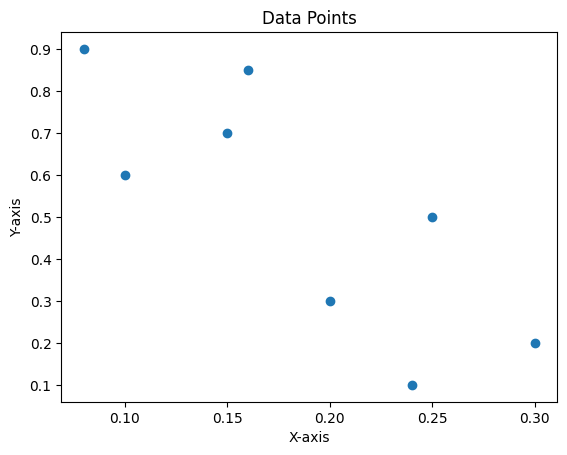

In [ ]:
# Plot the data points on graph
plt.plot(x, y, 'o')   # 'o' means circle points
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Data Points")
plt.show()

In [ ]:
# Function to calculate Euclidean distance
def euclidean_distance(x1, y1, x2, y2):
    return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)


# Function to calculate Manhattan distance
def manhattan_distance(x1, y1, x2, y2):
    return abs(x1 - x2) + abs(y1 - y2)

In [ ]:
# Function to decide which cluster a point belongs to
def findCluster(m1, m2, x_co, y_co):

    # Distance from centroid 1
    d1 = manhattan_distance(m1[0], m1[1], x_co, y_co)

    # Distance from centroid 2
    d2 = manhattan_distance(m2[0], m2[1], x_co, y_co)

    # Assign to nearest cluster
    if d1 < d2:
        return 1
    else:
        return 2

In [ ]:
# Initial centroids (starting points)
m1 = [0.1, 0.6]
m2 = [0.3, 0.2]

In [ ]:
difference = math.inf   # Start with very large value
threshold = 0.02        # Stopping condition
iteration = 0           # Count iterations

# Combine x and y into single array of points
points = np.column_stack((x, y))

In [ ]:
# Initial centroids (starting points)
m1 = [0.1, 0.6]
m2 = [0.3, 0.2]

difference = math.inf   # Start with very large value
threshold = 0.02        # Stopping condition
iteration = 0           # Count iterations

# Combine x and y into single array of points
points = np.column_stack((x, y))

# Repeat until centroids stabilize
while(difference > threshold):

    print("Iteration", iteration, ": m1=", m1, " m2=", m2)

    cluster1 = []
    cluster2 = []

    # Check each point
    for i in range(0, np.size(x)):
        clusterNumber = findCluster(m1, m2, x[i], y[i])
        point = [x[i], y[i]]

        if clusterNumber == 1:
            cluster1.append(point)   # Add to cluster 1
        else:
            cluster2.append(point)   # Add to cluster 2

    print("Cluster 1:", cluster1)
    print("Cluster 2:", cluster2)

    # Save old centroids
    m1_old = m1
    m2_old = m2

    # New centroid = mean of cluster points
    m1 = np.mean(cluster1, axis=0)
    m2 = np.mean(cluster2, axis=0)

    print("m1 =", m1, " m2 =", m2)

    xAvg = 0.0
    yAvg = 0.0

    # Average change in X
    xAvg = math.fabs(m1[0] - m1_old[0]) + math.fabs(m2[0] - m2_old[0])
    xAvg = xAvg / 2

    # Average change in Y
    yAvg = math.fabs(m1[1] - m1_old[1]) + math.fabs(m2[1] - m2_old[1])
    yAvg = yAvg / 2

    # Take maximum shift
    if(xAvg > yAvg):
        difference = xAvg
    else:
        difference = yAvg

    print("Difference :", difference)
    print("")

    iteration += 1

print("Final Output")
print("Cluster 1 centroid :", m1)
print("Cluster 1 points :", cluster1)
print("Cluster 2 centroid :", m2)
print("Cluster 2 points :", cluster2)

# Convert clusters into arrays
clust1 = np.array(cluster1)
clust2 = np.array(cluster2)

In [ ]:
# Repeat until centroids stabilize
while(difference>threshold):

    print("Iteration",iteration,": m1=",m1," m2=",m2)

    cluster1=[]
    cluster2=[]

In [ ]:
    # Check each point
    for i in range(0,np.size(x)):

        clusterNumber = findCluster(m1,m2,x[i],y[i])
        point=[x[i],y[i]]

        if clusterNumber==1:
            cluster1.append(point)   # Add to cluster 1
        else:
            cluster2.append(point)   # Add to cluster 2

    print("Cluster 1:",cluster1)
    print("Cluster 2:",cluster2)

Cluster 1: [[np.float64(0.1), np.float64(0.6)], [np.float64(0.15), np.float64(0.7)], [np.float64(0.08), np.float64(0.9)], [np.float64(0.16), np.float64(0.85)]]
Cluster 2: [[np.float64(0.2), np.float64(0.3)], [np.float64(0.25), np.float64(0.5)], [np.float64(0.24), np.float64(0.1)], [np.float64(0.3), np.float64(0.2)]]


In [ ]:
    # Save old centroids
    m1_old=m1
    m2_old=m2

In [ ]:
    # New centroid = mean of cluster points
    m1=np.mean(cluster1,axis=0)
    m2=np.mean(cluster2,axis=0)

    print("m1 =",m1," m2 =",m2)

m1 = [0.1225 0.7625]  m2 = [0.2475 0.275 ]


In [ ]:
    # New centroid = mean of cluster points
    m1=np.mean(cluster1,axis=0)
    m2=np.mean(cluster2,axis=0)

    print("m1 =",m1," m2 =",m2)

m1 = [0.1225 0.7625]  m2 = [0.2475 0.275 ]


In [ ]:
    xAvg=0.0
    yAvg=0.0

    # Average change in X
    xAvg=math.fabs(m1[0]-m1_old[0])+math.fabs(m2[0]-m2_old[0])
    xAvg=xAvg/2

    # Average change in Y
    yAvg=math.fabs(m1[1]-m1_old[1])+math.fabs(m2[1]-m2_old[1])
    yAvg=yAvg/2

    # Take maximum shift
    if(xAvg>yAvg):
        difference=xAvg
    else:
        difference=yAvg

    print("Difference :",difference)
    print("")

    iteration+=1

Difference : 0.06374999999999999



In [ ]:
print("Final Output")
print("Cluster 1 centroid :",m1)
print("Cluster 1 points :",cluster1)
print("Cluster 2 centroid :",m2)
print("Cluster 2 points :",cluster2)

Final Output
Cluster 1 centroid : [0.1225 0.7625]
Cluster 1 points : [[np.float64(0.1), np.float64(0.6)], [np.float64(0.15), np.float64(0.7)], [np.float64(0.08), np.float64(0.9)], [np.float64(0.16), np.float64(0.85)]]
Cluster 2 centroid : [0.2475 0.275 ]
Cluster 2 points : [[np.float64(0.2), np.float64(0.3)], [np.float64(0.25), np.float64(0.5)], [np.float64(0.24), np.float64(0.1)], [np.float64(0.3), np.float64(0.2)]]


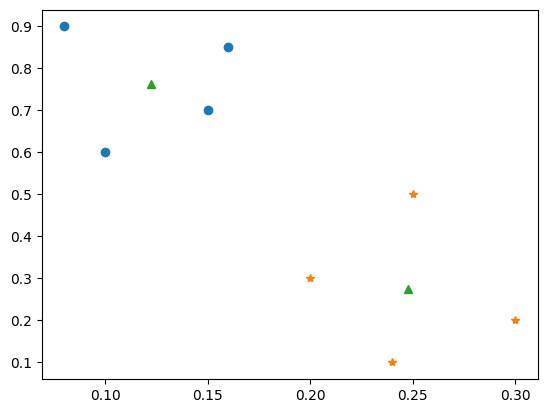

In [ ]:
# Convert clusters into arrays
clust1=np.array(cluster1)
clust2=np.array(cluster2)

# Plot cluster points
plt.plot(clust1[:,0],clust1[:,1],"o")   # Cluster 1
plt.plot(clust2[:,0],clust2[:,1],"*")   # Cluster 2

# Plot centroids
plt.plot([m1[0],m2[0]],[m1[1],m2[1]],"^")

plt.show()